In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns',None)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
energy_efficiency = fetch_ucirepo(id=242)

# data (as pandas dataframes)
x = energy_efficiency.data.features
y = energy_efficiency.data.targets

# metadata
print(energy_efficiency.metadata)

# variable information
print(energy_efficiency.variables)


{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

In [7]:
x.head()

,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [8]:
y.head()

,Y1,Y2
0,15.55,21.33
1,15.55,21.33
2,15.55,21.33
3,15.55,21.33
4,20.84,28.28


In [9]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.1 KB


<Axes: ylabel='Density'>

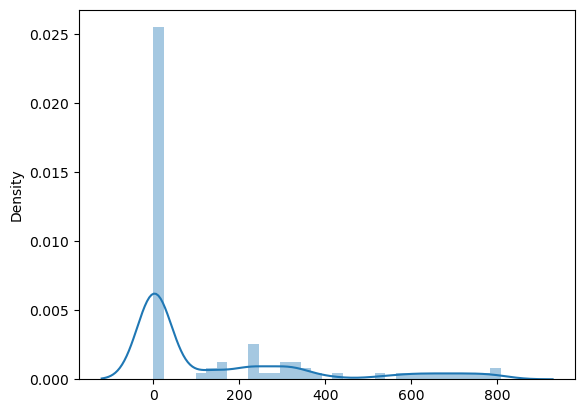

In [10]:
sns.distplot(x)

In [11]:
def handle_outliers_df(df):
    numerical_cols = df.select_dtypes(include='number').columns
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Calculate the median of the column
        median = df[col].median()

        # Replace outliers with the median
        df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), median, df[col])
    return df

<Axes: ylabel='Density'>

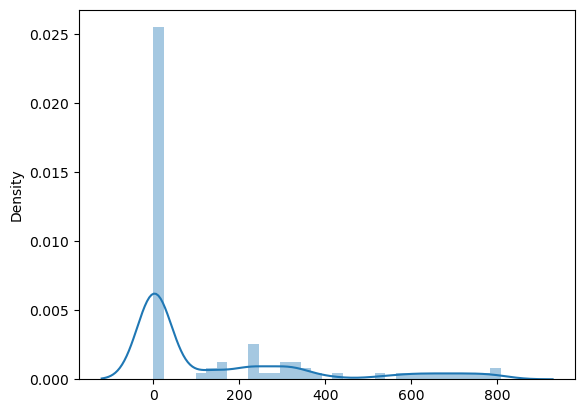

In [12]:
x = handle_outliers_df(x)
sns.distplot(x)

In [13]:
def zero_center(x):
  return x -np.mean(x,axis=0)
def whiten2(x,correct=True):
  xc = zero_center(x)
  _,l,vt = np.linalg.svd(np.dot(xc.T,xc))
  w = np.dot(vt.T / np.sqrt(l),vt)

  return np.dot(xc,w)*np.sqrt(x.shape[0]) if correct else 1.0

<Axes: ylabel='Density'>

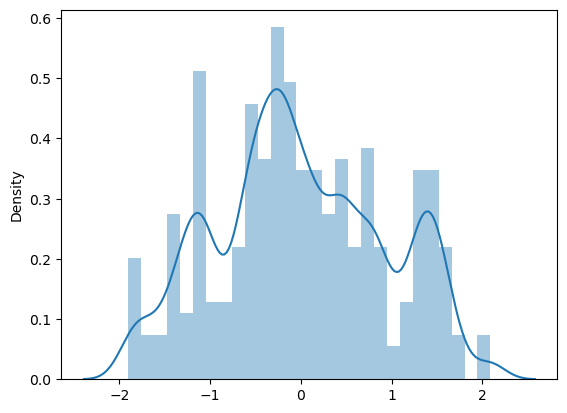

In [14]:
sns.distplot(whiten2(x))

In [15]:
x= whiten2(x)
x=pd.DataFrame(x)
x.head()

,0,1,2,3,4,5,6,7
0,1.247251,-1.661851,-0.386586,-0.637572,-1.812080,-1.341641,-1.436686,-1.790588
1,1.247251,-1.661851,-0.386586,-0.637572,-1.812080,-0.447214,-1.436686,-1.790588
2,1.247251,-1.661851,-0.386586,-0.637572,-1.812080,0.447214,-1.436686,-1.790588
3,1.247251,-1.661851,-0.386586,-0.637572,-1.812080,1.341641,-1.436686,-1.790588
4,0.119689,-1.112367,0.083882,-0.598120,-0.692684,-1.341641,-1.436686,-1.790588


In [16]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
x = sc.fit_transform(x)
x = pd.DataFrame(x)
x.head()

,0,1,2,3,4,5,6,7
0,0.865374,1.110223e-16,0.321949,0.214353,1.221245e-15,0.000000,1.165734e-15,1.110223e-16
1,0.865374,1.110223e-16,0.321949,0.214353,1.221245e-15,0.333333,1.498801e-15,1.110223e-16
2,0.865374,1.110223e-16,0.321949,0.214353,1.221245e-15,0.666667,1.887379e-15,0.000000e+00
3,0.865374,0.000000e+00,0.321949,0.214353,1.221245e-15,1.000000,2.220446e-15,0.000000e+00
4,0.555386,1.755555e-01,0.450771,0.235966,3.306222e-01,0.000000,3.108624e-15,1.110223e-16


<Axes: ylabel='Density'>

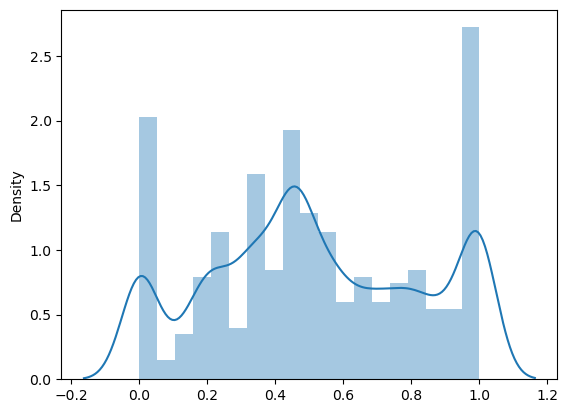

In [17]:
sns.distplot(x)

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet, BayesianRidge, ARDRegression, PassiveAggressiveRegressor, HuberRegressor, TheilSenRegressor, RANSACRegressor
from sklearn.kernel_ridge import KernelRidge

In [19]:
from sklearn.multioutput import MultiOutputRegressor

def k_fold_cv_multioutput(X, y, fold=5):
    model_name = ['Linear Regression', 'Lasso', 'Ridge', 'DTR', 'SVR', 'KNN', 'Random Forest', 'Gradient Boost',
                  'ADA Boost', 'XG', 'ElasticNet', 'BayesianRidge', 'ARDRegression', 'PassiveAggressiveRegressor',
                  'HuberRegressor', 'TheilSenRegressor', 'RANSACRegressor', 'KernelRidge']

    models = [
        LinearRegression(), Lasso(), Ridge(), DecisionTreeRegressor(), SVR(), KNeighborsRegressor(),
        RandomForestRegressor(), GradientBoostingRegressor(), AdaBoostRegressor(), XGBRegressor(),
        ElasticNet(), BayesianRidge(), ARDRegression(), PassiveAggressiveRegressor(), HuberRegressor(),
        TheilSenRegressor(), RANSACRegressor(), KernelRidge()
    ]

    result = []
    for i in range(len(model_name)):
        # Wrap the model with MultiOutputRegressor
        multi_output_model = MultiOutputRegressor(models[i])

        score = cross_val_score(multi_output_model, X, y, cv=fold)
        score_mean = np.mean(score)
        score_std = np.std(score)
        m_name = model_name[i]
        temp = [m_name, score_mean, score_std]
        result.append(temp)

    k_fold_df = pd.DataFrame(result, columns=['Model Name', 'CV Accuracy', 'CV STD'])
    return k_fold_df.sort_values('CV Accuracy', ascending=False)

k_fold_results = k_fold_cv_multioutput(x, y)
k_fold_results

,Model Name,CV Accuracy,CV STD
7,Gradient Boost,0.961660,0.038062
6,Random Forest,0.953224,0.042062
9,XG,0.946475,0.038955
3,DTR,0.942631,0.043638
8,ADA Boost,0.929929,0.062163
5,KNN,0.906461,0.081997
14,HuberRegressor,0.884221,0.036538
0,Linear Regression,0.884210,0.035522
11,BayesianRidge,0.882759,0.035861
2,Ridge,0.882574,0.036112


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, BayesianRidge, ARDRegression, PassiveAggressiveRegressor, HuberRegressor, TheilSenRegressor, RANSACRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.kernel_ridge import KernelRidge
from scipy.stats import loguniform, randint, uniform
from sklearn.multioutput import MultiOutputRegressor

def tuning_regressor(X, y, fold=10):
    param_dist = {
        'Lasso': {
            'estimator__alpha': loguniform(1e-2, 1e2),
            'estimator__selection': ['cyclic', 'random'],
            'estimator__max_iter': [1000, 5000]
        },
        'Ridge': {
            'estimator__alpha': loguniform(1e-2, 1e2),
            'estimator__solver': ['svd', 'cholesky', 'lsqr']
        },
        'KNeighborsRegressor': {
            'estimator__n_neighbors': randint(3, 15),
            'estimator__weights': ['uniform', 'distance'],
            'estimator__p': [1, 2]
        },
        'DecisionTreeRegressor': {
            'estimator__max_depth': randint(3, 12),
            'estimator__min_samples_split': randint(2, 10),
            'estimator__min_samples_leaf': randint(1, 5),
            'estimator__criterion': ['squared_error', 'friedman_mse']
        },
        'SVR': {
            'estimator__C': loguniform(1e-1, 1e2),
            'estimator__gamma': loguniform(1e-3, 1e3),
            'estimator__kernel': ['linear', 'rbf'],
            'estimator__epsilon': loguniform(1e-2, 1e2)
        },
        'AdaBoostRegressor': {
            'estimator__n_estimators': randint(50, 150),
            'estimator__learning_rate': loguniform(1e-2, 1e0),
            'estimator__loss': ['linear', 'square']
        },
        'GradientBoostingRegressor': {
            'estimator__n_estimators': randint(50, 150),
            'estimator__learning_rate': loguniform(1e-2, 1e0),
            'estimator__max_depth': randint(3, 8),
            'estimator__subsample': uniform(0.6, 0.4),
            'estimator__min_samples_split': randint(2, 10),
            'estimator__min_samples_leaf': randint(1, 5)
        },
        'XGBRegressor': {
            'estimator__n_estimators': randint(50, 150),
            'estimator__learning_rate': loguniform(1e-2, 1e0),
            'estimator__max_depth': randint(3, 8),
            'estimator__subsample': uniform(0.6, 0.4),
            'estimator__colsample_bytree': uniform(0.6, 0.4),
            'estimator__gamma': loguniform(1e-2, 1e2),
            'estimator__reg_alpha': loguniform(1e-2, 1e2),
            'estimator__reg_lambda': loguniform(1e-2, 1e2)
        },
        'RandomForestRegressor': {
            'estimator__n_estimators': randint(50, 150),
            'estimator__max_depth': randint(5, 15),
            'estimator__min_samples_split': randint(2, 10),
            'estimator__min_samples_leaf': randint(1, 5),
            'estimator__max_features': ['auto', 'sqrt']
        },
        'LinearRegression': {},
        'ElasticNet': {
            'estimator__alpha': loguniform(1e-2, 1e2),
            'estimator__l1_ratio': uniform(0.1, 0.9)
        },
        'BayesianRidge': {
            'estimator__alpha_1': loguniform(1e-6, 1e-2),
            'estimator__alpha_2': loguniform(1e-6, 1e-2),
            'estimator__lambda_1': loguniform(1e-6, 1e-2),
            'estimator__lambda_2': loguniform(1e-6, 1e-2)
        },
        'ARDRegression': {
            'estimator__alpha_1': loguniform(1e-6, 1e-2),
            'estimator__alpha_2': loguniform(1e-6, 1e-2),
            'estimator__lambda_1': loguniform(1e-6, 1e-2),
            'estimator__lambda_2': loguniform(1e-6, 1e-2)
        },
        'PassiveAggressiveRegressor': {
            'estimator__C': loguniform(1e-2, 1e2),
            'estimator__max_iter': [1000, 5000],
            'estimator__tol': [1e-3, 1e-4]
        },
        'HuberRegressor': {
            'estimator__epsilon': uniform(1.1, 2.0),
            'estimator__alpha': loguniform(1e-2, 1e2)
        },
        'TheilSenRegressor': {
            'estimator__max_subpopulation': [10000, 50000],
            'estimator__n_subsamples': randint(50, 200)
        },
        'RANSACRegressor': {
            'estimator__min_samples': uniform(0.1, 0.9),
            'estimator__residual_threshold': loguniform(1e-1, 1e2)
        },
        'KernelRidge': {
            'estimator__alpha': loguniform(1e-2, 1e2),
            'estimator__kernel': ['linear', 'rbf', 'poly'],
            'estimator__gamma': loguniform(1e-3, 1e3)
        }
    }

    models = [
        Lasso(),
        Ridge(),
        KNeighborsRegressor(),
        DecisionTreeRegressor(),
        SVR(),
        AdaBoostRegressor(),
        GradientBoostingRegressor(),
        XGBRegressor(),
        RandomForestRegressor(),
        LinearRegression(),
        ElasticNet(),
        BayesianRidge(),
        ARDRegression(),
        PassiveAggressiveRegressor(),
        HuberRegressor(),
        TheilSenRegressor(),
        RANSACRegressor(),
        KernelRidge()
    ]

    model_names = [
        'Lasso',
        'Ridge',
        'KNeighborsRegressor',
        'DecisionTreeRegressor',
        'SVR',
        'AdaBoostRegressor',
        'GradientBoostingRegressor',
        'XGBRegressor',
        'RandomForestRegressor',
        'LinearRegression',
        'ElasticNet',
        'BayesianRidge',
        'ARDRegression',
        'PassiveAggressiveRegressor',
        'HuberRegressor',
        'TheilSenRegressor',
        'RANSACRegressor',
        'KernelRidge'
    ]

    results = []

    for model, model_name in zip(models, model_names):
        current_param_dist = param_dist.get(model_name, {})

        multi_output_model = MultiOutputRegressor(model)

        random_search = RandomizedSearchCV(
            multi_output_model, param_distributions=current_param_dist,
            cv=fold, scoring='r2', random_state=42, n_jobs=-1
        )
        random_search.fit(X, y)
        results.append([model_name, random_search.best_params_, random_search.best_score_])

    tuning_results_df = pd.DataFrame(results, columns=['Model Name', 'Best Parameters', 'Best R2'])
    return tuning_results_df.sort_values('Best R2', ascending=False)

tuning_results = tuning_regressor(x, y)
tuning_results.head(17)

In [ ]:
# List of models
from sklearn.linear_model import Lasso, Ridge, ElasticNet, BayesianRidge, ARDRegression, PassiveAggressiveRegressor, HuberRegressor, TheilSenRegressor, RANSACRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression  # Import LinearRegression

best_params = tuning_results.set_index('Model Name')['Best Parameters'].to_dict()

# Modify best_params to remove the 'estimator__' prefix
modified_best_params = {}
for model_name, params in best_params.items():
    modified_params = {}
    for param_name, param_value in params.items():
        modified_param_name = param_name.replace('estimator__', '')
        modified_params[modified_param_name] = param_value
    modified_best_params[model_name] = modified_params

# Update the models dictionary with the best parameters, including missing models
models = {
    'Linear Regression': LinearRegression(),  # Add LinearRegression
    'Lasso': Lasso(**modified_best_params['Lasso']), # Use modified_best_params
    'Ridge': Ridge(**modified_best_params['Ridge']), # Use modified_best_params
    'ElasticNet': ElasticNet(**modified_best_params['ElasticNet']),  # Add ElasticNet
    'BayesianRidge': BayesianRidge(**modified_best_params['BayesianRidge']),  # Add BayesianRidge
    'ARDRegression': ARDRegression(**modified_best_params['ARDRegression']),  # Add ARDRegression
    'PassiveAggressiveRegressor': PassiveAggressiveRegressor(**modified_best_params['PassiveAggressiveRegressor']),  # Add PassiveAggressiveRegressor
    'HuberRegressor': HuberRegressor(**modified_best_params['HuberRegressor']),  # Add HuberRegressor
    'TheilSenRegressor': TheilSenRegressor(**modified_best_params['TheilSenRegressor']),  # Add TheilSenRegressor
    'RANSACRegressor': RANSACRegressor(**modified_best_params['RANSACRegressor']),  # Add RANSACRegressor
    'KernelRidge': KernelRidge(**modified_best_params['KernelRidge']),  # Add KernelRidge
    'KNN': KNeighborsRegressor(**modified_best_params['KNeighborsRegressor']),
    'DTR': DecisionTreeRegressor(**modified_best_params['DecisionTreeRegressor']),
    'SVR': SVR(**modified_best_params['SVR']),
    'ADBR': AdaBoostRegressor(**modified_best_params['AdaBoostRegressor']),
    'GBR': GradientBoostingRegressor(**modified_best_params['GradientBoostingRegressor']),
    'XGBR': XGBRegressor(**modified_best_params['XGBRegressor'])
}

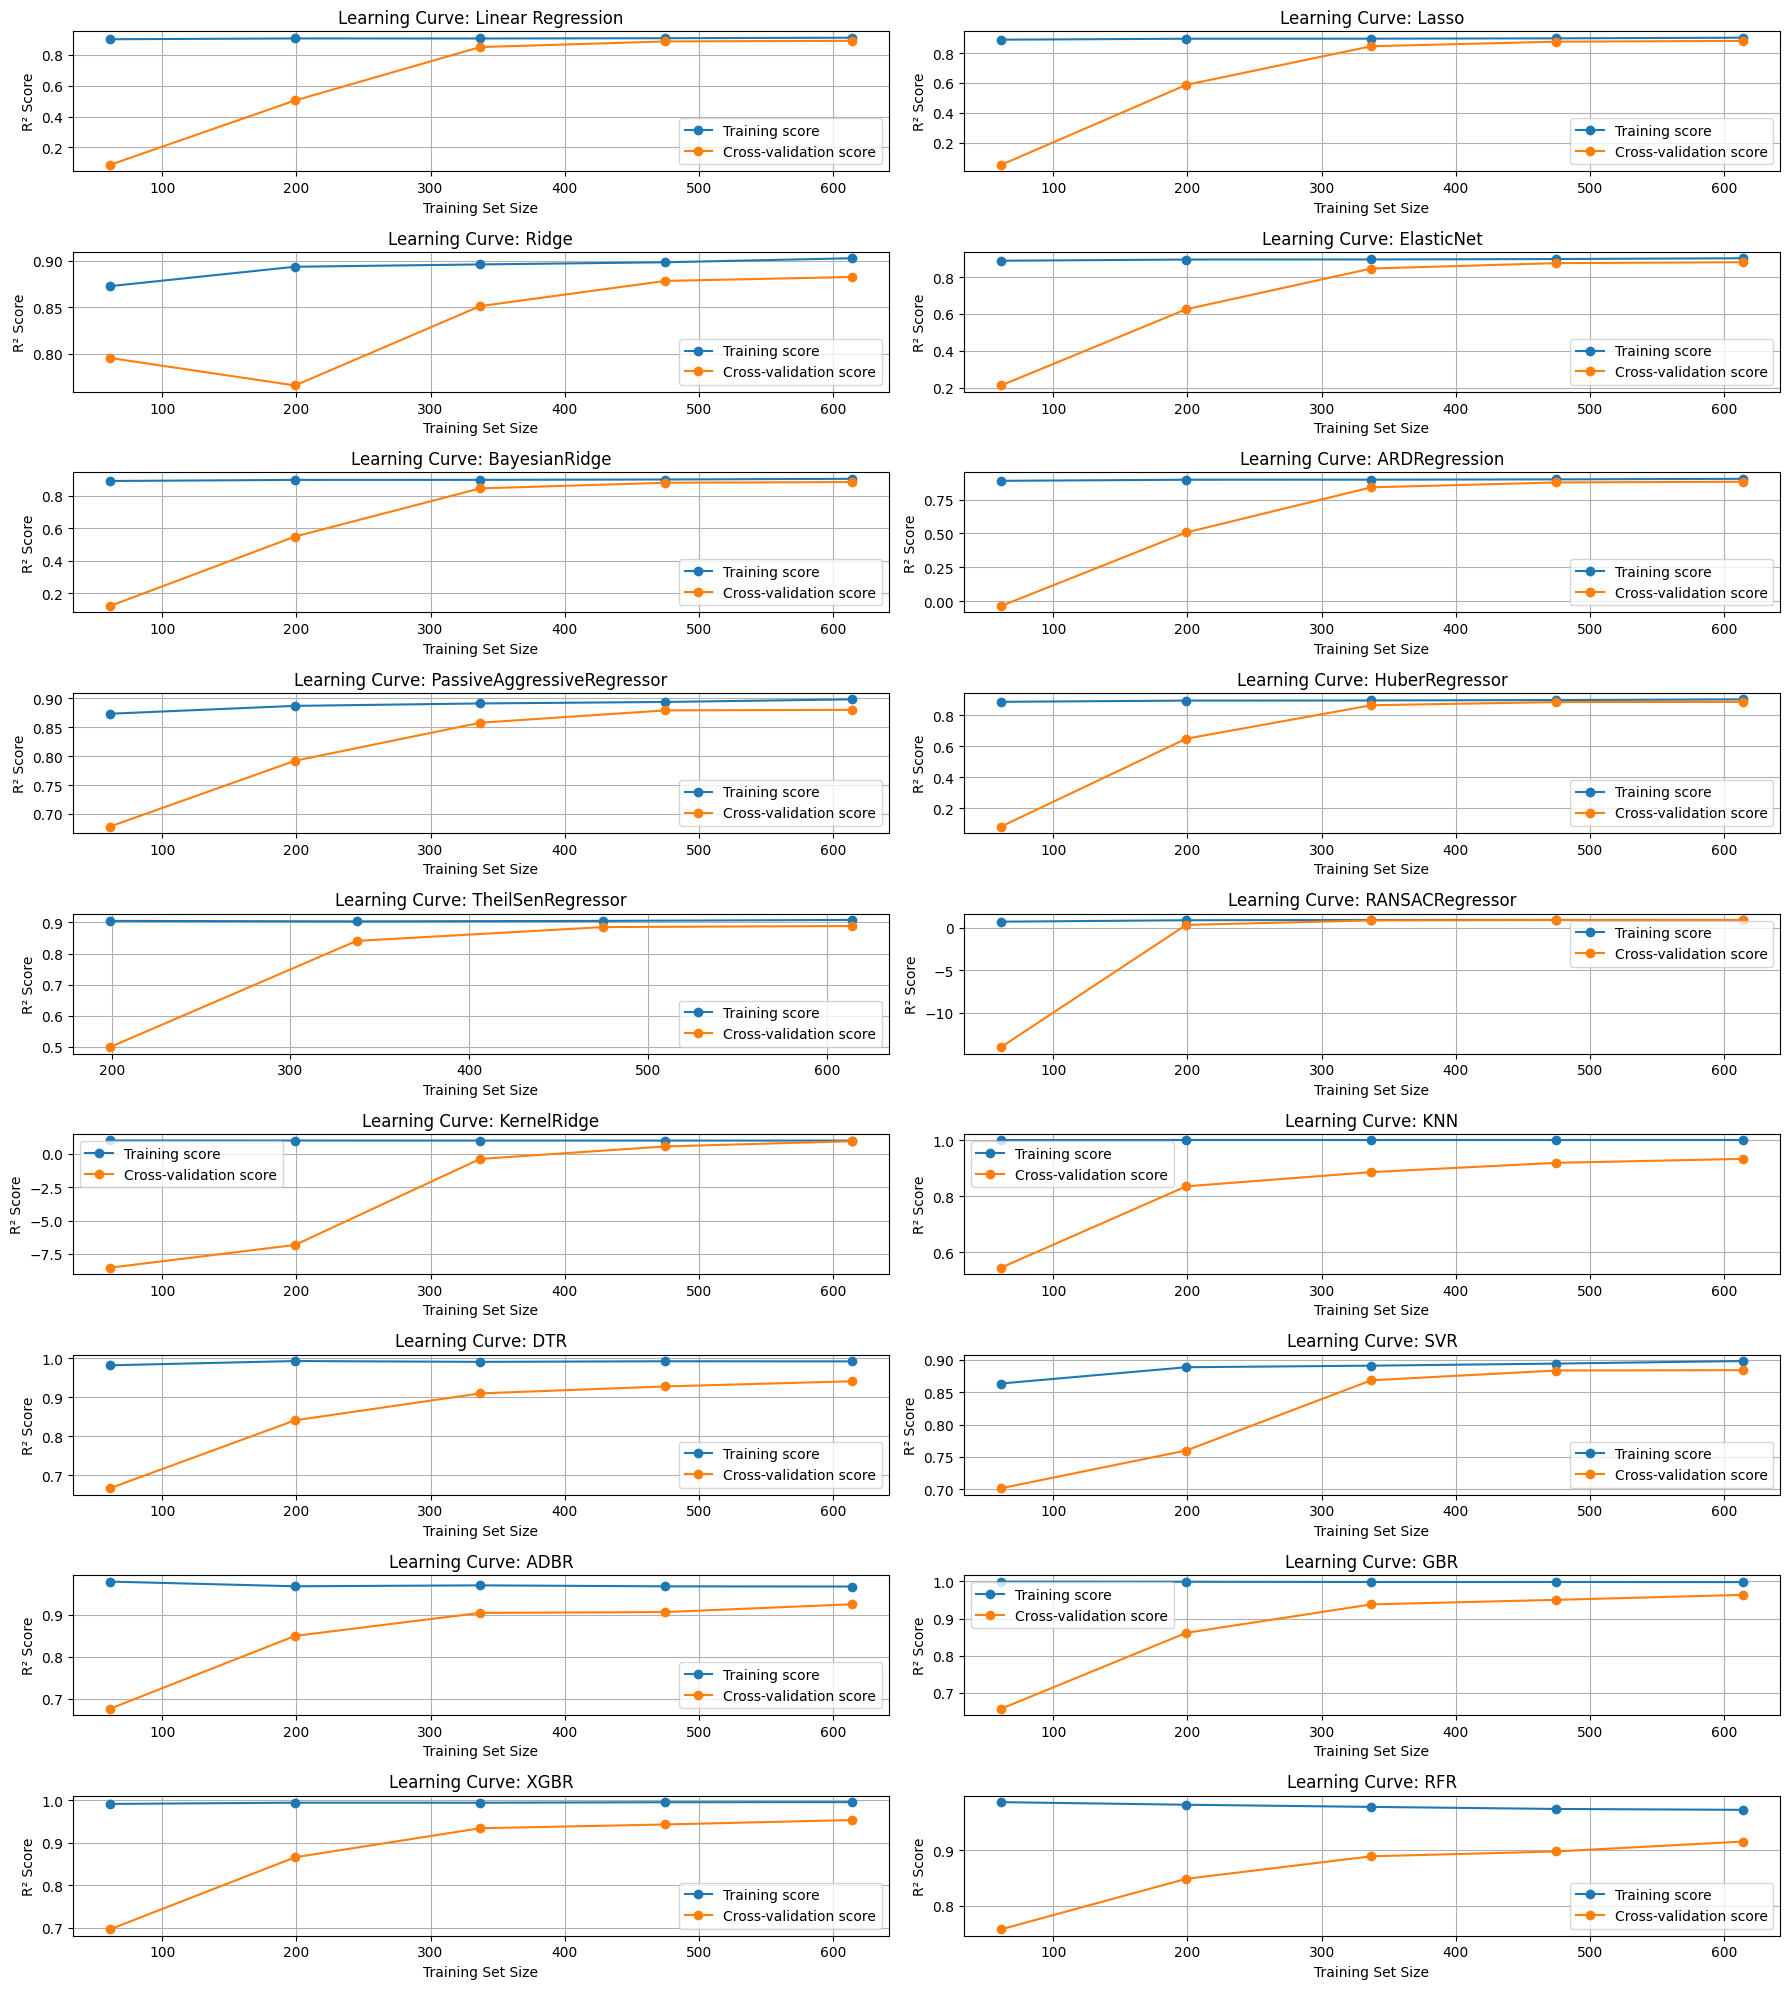

In [ ]:
# Plotting Learning Rate
# Plot learning curves
from sklearn.model_selection import learning_curve
import math  # Import math for ceil function
from sklearn.multioutput import MultiOutputRegressor  # Import MultiOutputRegressor

plt.figure(figsize=(18, 20))
num_models = len(models)  # Get the total number of models
num_rows = math.ceil(num_models / 2)  # Calculate rows (round up)
# num_cols = 2

for i, (name, model) in enumerate(models.items()):
    # Use num_rows and 2 to create enough subplots
    plt.subplot(num_rows, 2, i + 1)

    # Wrap the model with MultiOutputRegressor if it's not already wrapped
    if not isinstance(model, MultiOutputRegressor):
        model = MultiOutputRegressor(model)

    train_sizes, train_scores, test_scores = learning_curve(
        model, x, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='r2'
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', label='Cross-validation score')
    plt.title(f'Learning Curve: {name}')
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.legend(loc='best')
    plt.grid()

plt.tight_layout()
plt.show()